## Generate input images for aberration-resilience testing of CFCNN - single point

* In this notebook, we define the tested range of aberrations and use them to generate single-PSF images.
* Here we assume strong signals, i.e., virtually noiseless images.
* We study astigmatism, coma, defocus, and spherical aberration.
* Resulting images are saved in `data/` and subsequently processed by `process_inputs_cnn.py`.
* PSF model is defined in `psf_toolbox_v3.py`.

In [1]:
import numpy as np
from numpy.fft import fftshift, ifft2, ifftshift
import matplotlib.pyplot as plt
import h5py
from psf_toolbox_v3 import psf_high_NA_vector, render_psf_emitters, scaled_psf_vector
from tqdm import tqdm

/cluster/home/starek/decodeenv/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.25.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


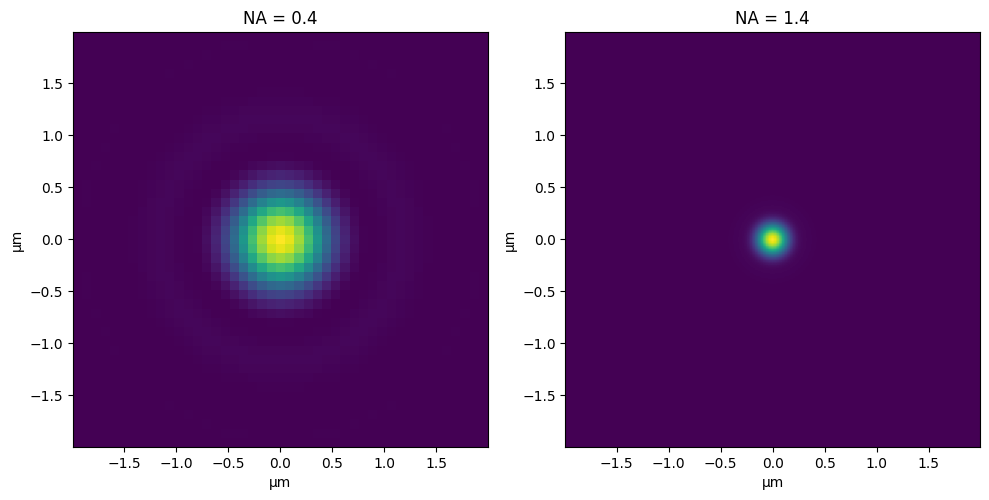

In [2]:
# Compute PSFs
psf_low, x_low, y_low = psf_high_NA_vector(NA=0.4, A_ast=0.0)
psf_high, x_high, y_high = psf_high_NA_vector(NA=1.4, A_ast=0.0)

# Define zoom range in µm
zoom_range = 2.0  # ± range from center

ix_low = np.where((x_low >= -zoom_range) & (x_low <= zoom_range))[0]
iy_low = np.where((y_low >= -zoom_range) & (y_low <= zoom_range))[0]
ix_high = np.where((x_high >= -zoom_range) & (x_high <= zoom_range))[0]
iy_high = np.where((y_high >= -zoom_range) & (y_high <= zoom_range))[0]

# Plot zoomed PSFs
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

im1 = axs[0].imshow(psf_low[np.ix_(iy_low, ix_low)],
                    extent=[x_low[ix_low[0]], x_low[ix_low[-1]],
                            y_low[iy_low[0]], y_low[iy_low[-1]]],
                    origin='lower')
axs[0].set_title("NA = 0.4")
axs[0].set_xlabel("µm")
axs[0].set_ylabel("µm")

im2 = axs[1].imshow(psf_high[np.ix_(iy_high, ix_high)],
                    extent=[x_high[ix_high[0]], x_high[ix_high[-1]],
                            y_high[iy_high[0]], y_high[iy_high[-1]]],
                    origin='lower')
axs[1].set_title("NA = 1.4")
axs[1].set_xlabel("µm")
axs[1].set_ylabel("µm")

plt.tight_layout()
plt.show()

In [3]:
base_size = 50
scale = 4
up_size = base_size * scale

# Coordinates of emitter in 50x50 (center)
x_base, y_base = base_size / 2, base_size / 2
intensity = 1.0

# Upscale coordinates with shift to keep center aligned
shift = (scale - 1) / 2
#shift = int((scale - 1) / 2)
x_up = x_base * scale + shift
y_up = y_base * scale + shift

# Create upscaled image and place emitter
image = np.zeros((up_size, up_size), dtype=np.float32)
image[int(round(y_up)), int(round(x_up))] = intensity


num_psfs = 30
img_size = base_size
abberations = {
    'A_coma_x' :  np.linspace(0.0, 0.3, num_psfs),
    'A_ast' : np.linspace(0.0, 0.3, num_psfs),
    'A_sph' : np.linspace(0.0, 0.3, num_psfs),    
    'A_def' : np.linspace(0.0, 0.3, num_psfs)
}

with h5py.File('data/single_point_psf_for_cnn.h5', 'w') as h5f:
    dset_aber_size = h5f.create_dataset('abberation_size', data = abberations['A_def'])
    dset_reference = h5f.create_dataset('reference', data = image)
    
    for key in abberations:
        print(key)
        A_values = abberations[key]
        psf_stack = np.zeros((A_values.shape[0], img_size, img_size), dtype=np.float32)
        for i, A_ast in tqdm(enumerate(A_values), total=A_values.shape[0]):
            psf, dx = scaled_psf_vector(px_size_um=0.059, NA=1.4, n=1.5, **{key : A_ast})
            psf_stack[i] = psf
        h5f.create_dataset(key, data=psf_stack)

A_coma_x


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:20<00:00,  1.48it/s]


A_ast


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:20<00:00,  1.46it/s]


A_sph


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:20<00:00,  1.45it/s]


A_def


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:20<00:00,  1.45it/s]


In [4]:
def generate_gt_image(xyi, h, w):
    """
    Generate a ground truth image by placing intensities at specified coordinates.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains three values 
                              (x, y, intensity). `x` and `y` are the coordinates, and 
                              `intensity` is the value to be added at that position.
        h (int): The height of the output image.
        w (int): The width of the output image.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, 
                       normalized such that the sum of all pixel values equals 1.

    Notes:
        - The function rounds the `x` and `y` coordinates to the nearest integer 
          to determine the pixel location.
        - If the rounded coordinates fall outside the image dimensions, they are ignored.
        - The resulting image is normalized by dividing all pixel values by the total sum.
    """
    img = np.zeros((h, w))
    for x, y, intensity in xyi:
        x_nearest = int(np.round(x))
        y_nearest = int(np.round(y))
        if (x_nearest <= w-1) and (y_nearest <= h-1):
            img[y_nearest, x_nearest] += intensity
    return img/np.sum(img)


def upscale_xyi(xyi, scale=4):
    """
    Upscales the x and y coordinates of a list of [x, y, i] elements by a given scale factor.

    This function takes a list of [x, y, i] elements, where x and y are coordinates and i is an 
    additional value, and scales the x and y coordinates by the specified scale factor. A shift 
    is applied to center the scaled coordinates.

    Args:
        xyi (list of lists or tuples): A list of [x, y, i] elements to be upscaled.
        scale (int, optional): The scale factor to upscale the x and y coordinates. Defaults to 4.

    Returns:
        list: A list of upscaled [x, y, i] elements with the same structure as the input.
    """
    xyiarr = np.array(xyi)
    shift = int((scale-1)/2)
    xyiarr[:, 0] = xyiarr[:, 0]*scale + shift
    xyiarr[:, 1] = xyiarr[:, 1]*scale + shift
    return list(xyiarr)

In [ ]:
px_size_um = 0.15
NA_values = np.linspace(0.3, 1.0, 28) 
n = 1.5
xyi = np.array([(25,25,1e6)])
imggt = generate_gt_image(upscale_xyi(xyi, scale), up_size, up_size)

# Generate stack
psf_stack = []
for NA in tqdm(NA_values):
    psf, _dx = scaled_psf_vector(px_size_um=px_size_um, NA=NA, n=n)    
    psf_stack.append(psf)
psf_stack = np.array(psf_stack)  # shape: (len(NA_values), 50, 50)

# Save to HDF5
with h5py.File("data/input_for_cnn_psf_NA.h5", "w") as f:
    f.create_dataset("psfs", data=psf_stack)
    f.create_dataset("NA_values", data=NA_values)
    f.create_dataset('imggt', data=imggt)
    f.attrs["pixel_size_um"] = px_size_um
    f.attrs["description"] = "PSFs from psf_high_NA_vector, centered, 50x50 px, varying NA"

print("Saved psf_stack.h5 with shape", psf_stack.shape)

100%|███████████████████████████████████████████████████████████████████████████████████| 28/28 [00:17<00:00,  1.65it/s]

Saved psf_stack.h5 with shape (28, 50, 50)


## Generate star pattern synthetic data for testing the resilience to aberrations

In [6]:
MONTE_CARLO_SAMPLES = 1

WIDTH = 50
HEIGTH = 50
BCKG = 0
UPSCALE = 4
DEG = np.pi/180.
THETA_STEP = 45*DEG
snrs = 1_000_000
snrs_mc = np.ones(MONTE_CARLO_SAMPLES)*snrs
noise_std = 0

params = {'width' : WIDTH, 'height' : HEIGTH, 'upscale' : UPSCALE, 'noise_std_scale' : noise_std, 'mc_samples' : MONTE_CARLO_SAMPLES}

# Generate coordinates of the star-shaped pattern.
xys = np.array([(25, 25)]+[(r*np.cos(THETA_STEP*i)+25, r*np.sin(THETA_STEP*i)+25)
               for i in range(8) for r in [6, 12, 18]])
xys = np.round(xys)
# Save the pattern parameters into numpy file.
np.savez('star_truth_info_new_star.npz', snrs=snrs_mc, xys=xys)

def add_snr_col(snr):
    """Add third column with SNR to an array of coordinates."""
    n = xys.shape[0]
    return np.hstack([xys, np.ones((n, 1))*snr])

num_psfs = 30
abberations = {
    'A_coma_x' :  np.linspace(0.0, 0.3, num_psfs),
    'A_ast' : np.linspace(0.0, 0.3, num_psfs),
    'A_sph' : np.linspace(0.0, 0.3, num_psfs),    
    'A_def' : np.linspace(0.0, 0.3, num_psfs)
}


In [ ]:
# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)
cwl = 580  # nm

# Helper routines for image generation
def l1norm(img):
    img = (img - np.min(img))
    return img/np.sum(img)
    
def generate_image(xyi, noise_mean, noise_std, psf, h, w, norm=False):
    """
    Generates a 2D image using PSF

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf (np.ndarray): The point spread function.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img0 = RNG.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)
    img_em = render_psf_emitters(xyi, psf, 50, 50)
    img = img0 + np.random.poisson(img_em)
    if not norm:
        return img
    return img/np.sum(img)

In [ ]:
# Generate aberrated images
snr = snrs
px_size_um=0.059
NA=1.4
n=1.5
stacks = {}

for key, _params in abberations.items():    
    subarr = []
    for p in tqdm(_params):
        _psf, _dx = scaled_psf_vector(px_size_um, NA, n, 0.58, **{key : p})
        _im = generate_image(add_snr_col(snr), 0, 0, _psf, HEIGTH, WIDTH)        
        subarr.append(_im)
    stacks[key] = np.array(subarr)

100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:22<00:00,  1.33it/s]


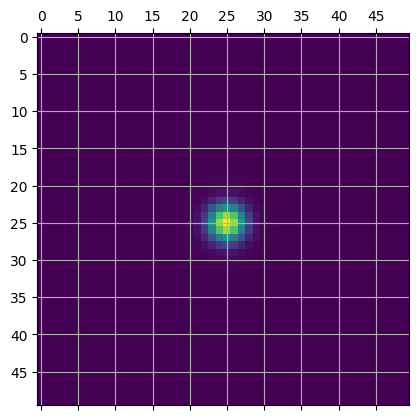

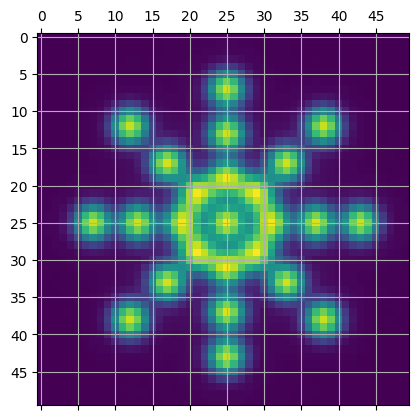

In [9]:
psf, _ = scaled_psf_vector(px_size_um, NA, n, 0.58)
plt.matshow(psf)
plt.xticks(np.arange(10)*5)
plt.yticks(np.arange(10)*5)
plt.grid()
plt.show()
im = generate_image(add_snr_col(1e6), 0, 0, psf, HEIGTH, WIDTH)  
plt.matshow(im)
plt.xticks(np.arange(10)*5)
plt.yticks(np.arange(10)*5)
plt.grid()
plt.show()


[[101. 101.  10.]
 [125. 101.  10.]
 [149. 101.  10.]
 [173. 101.  10.]
 [117. 117.  10.]
 [133. 133.  10.]
 [153. 153.  10.]
 [101. 125.  10.]
 [101. 149.  10.]
 [101. 173.  10.]
 [ 85. 117.  10.]
 [ 69. 133.  10.]
 [ 49. 153.  10.]
 [ 77. 101.  10.]
 [ 53. 101.  10.]
 [ 29. 101.  10.]
 [ 85.  85.  10.]
 [ 69.  69.  10.]
 [ 49.  49.  10.]
 [101.  77.  10.]
 [101.  53.  10.]
 [101.  29.  10.]
 [117.  85.  10.]
 [133.  69.  10.]
 [153.  49.  10.]]


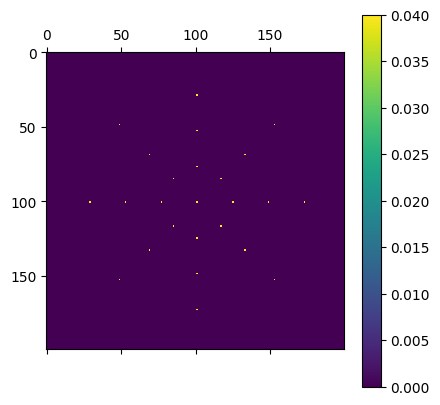

In [10]:
# Generate reference image
xyi = np.array(upscale_xyi(add_snr_col(10), scale=UPSCALE))
xyi.shape
print(xyi)
gtim = generate_gt_image(xyi, HEIGTH*UPSCALE, WIDTH*UPSCALE)
gtim.shape
plt.matshow(gtim)
plt.colorbar()

In [11]:
params = {'width' : WIDTH, 'height' : HEIGTH, 'upscale' : UPSCALE, 'noise_std_scale' : noise_std, 'mc_samples' : MONTE_CARLO_SAMPLES}
key = 'star_vs_snr'

with h5py.File('data/input_for_cnn_star_w_psfs.h5', 'w') as h5f:        
    h5f.create_dataset('reference', data=gtim, dtype=np.float32)
    dset_ref_pos = h5f.create_dataset('reference_pos', data=xys)
    dset_snrs = h5f.create_dataset('snrs', data=snrs_mc, dtype=np.float32)
    for key, aber_range in abberations.items():
        print(key)
        dset_aber_range = h5f.create_dataset(f'param_{key}', data=aber_range)
        dset_imgs = h5f.create_dataset(key, data=np.array([l1norm(img) for img in stacks[key]]))
    for pkey, val in params.items():
        print(pkey)
        h5f.attrs.create(f'gen_params_{pkey}', val)

A_coma_x
A_ast
A_sph
A_def
width
height
upscale
noise_std_scale
mc_samples
